# Bài 1.3 – Phân tích dữ liệu (EDA)

**Dataset:** `sklearn.datasets.load_breast_cancer()`

**Lưu ý:** Bài này **không train model**. Mục tiêu là *hiểu dữ liệu* trước khi làm bất cứ điều gì khác.

## Danh sách yêu cầu
| # | Yêu cầu | Vị trí trong notebook |
|---|---------|------------------------|
| 1 | In số sample, số feature, tên label | Phần 1 |
| 2 | Kiểm tra missing values | Phần 2 |
| 3 | Thống kê mean/std/min/max | Phần 3 |
| 4 | Đếm số lượng từng class | Phần 4 |
| 5 | 10 cặp feature có |correlation| cao nhất | Phần 5 |
| 6 | Histogram cho 5 feature | Phần 6 |
| 7 | Correlation matrix cho 10 feature đầu | Phần 7 |
| 8 | Viết 5 nhận xét | Phần 8 |

## Phần 0 – Nạp thư viện

In [1]:
# numpy: tính toán trên mảng số
import numpy as np

# pandas: làm việc với bảng dữ liệu (DataFrame)
import pandas as pd

# matplotlib: vẽ biểu đồ
import matplotlib.pyplot as plt

# Hàm nạp sẵn dataset ung thư vú của scikit-learn
from sklearn.datasets import load_breast_cancer

# Cho phép biểu đồ hiện trực tiếp trong notebook
%matplotlib inline

# Hiển thị số thực gọn lại cho dễ đọc
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Nạp thư viện thành công.")

Nạp thư viện thành công.


## Phần 1 – Nạp dữ liệu, in số sample / số feature / tên label

`load_breast_cancer()` trả về một đối tượng kiểu `Bunch`, hoạt động giống một dictionary với các khoá quan trọng:

- `data` – ma trận đặc trưng, kích thước (số sample × số feature)
- `target` – mảng nhãn, mỗi phần tử là 0 hoặc 1
- `feature_names` – tên 30 cột
- `target_names` – tên 2 lớp

Ta chuyển `data` sang **DataFrame** của pandas để có tên cột và các hàm thống kê tiện lợi.

In [2]:
data = load_breast_cancer()

# X = bảng feature (569 dòng x 30 cột), y = nhãn
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Số sample (số dòng)  :", X.shape[0])
print("Số feature (số cột)  :", X.shape[1])
print("Tên các label        :", list(data.target_names))
print("Quy ước mã hoá nhãn  : 0 =", data.target_names[0], "|  1 =", data.target_names[1])
print()
print("5 dòng đầu của dữ liệu (chỉ hiện vài cột đầu cho gọn):")
X.head()

Số sample (số dòng)  : 569
Số feature (số cột)  : 30
Tên các label        : [np.str_('malignant'), np.str_('benign')]
Quy ước mã hoá nhãn  : 0 = malignant |  1 = benign

5 dòng đầu của dữ liệu (chỉ hiện vài cột đầu cho gọn):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [3]:
# In đầy đủ tên 30 feature
print("DANH SÁCH 30 FEATURE:")
for i, ten in enumerate(data.feature_names, start=1):
    print(f"{i:2d}. {ten}")

DANH SÁCH 30 FEATURE:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


### Cấu trúc tên feature

30 feature thực chất chỉ là **10 phép đo gốc**, mỗi phép đo được thống kê theo 3 cách:

| Nhóm | Ý nghĩa | Số cột |
|------|---------|--------|
| `mean ...` | Giá trị trung bình của các nhân tế bào trong mẫu | 10 |
| `... error` | Sai số chuẩn của phép đo | 10 |
| `worst ...` | Trung bình của 3 giá trị lớn nhất (trường hợp xấu nhất) | 10 |

Đây là thông tin quan trọng: nó **giải thích trước** vì sao lát nữa ta sẽ thấy rất nhiều cặp feature tương quan cực cao.

## Phần 2 – Kiểm tra missing values

Missing value là ô không có giá trị (`NaN`). Nếu có, hầu hết thuật toán ML sẽ báo lỗi hoặc cho kết quả sai.

`isnull()` trả về bảng True/False cùng kích thước. `sum()` lần 1 cộng theo từng cột, `sum()` lần 2 cộng tất cả lại thành một số.

In [4]:
print("Tổng số ô bị thiếu trong toàn bộ bảng feature:", X.isnull().sum().sum())
print("Số ô bị thiếu ở cột nhãn (target)           :", y.isnull().sum())
print("Các kiểu dữ liệu xuất hiện trong bảng       :", X.dtypes.unique())

thieu = X.isnull().sum()
print()
if (thieu > 0).any():
    print("Các cột có missing value:")
    print(thieu[thieu > 0])
else:
    print("KẾT LUẬN: Không có cột nào bị thiếu dữ liệu.")

Tổng số ô bị thiếu trong toàn bộ bảng feature: 0
Số ô bị thiếu ở cột nhãn (target)           : 0
Các kiểu dữ liệu xuất hiện trong bảng       : [dtype('float64')]

KẾT LUẬN: Không có cột nào bị thiếu dữ liệu.


In [5]:
# Kiểm tra thêm: có giá trị vô cực (inf) không? Đây là dạng "bẩn" mà isnull() KHÔNG bắt được.
print("Số ô có giá trị vô cực (inf):", np.isinf(X.values).sum())

# Kiểm tra dòng trùng lặp hoàn toàn
print("Số dòng bị trùng lặp        :", X.duplicated().sum())

Số ô có giá trị vô cực (inf): 0
Số dòng bị trùng lặp        : 0


## Phần 3 – Thống kê mean / std / min / max

`describe()` tính sẵn 8 chỉ số cho mọi cột số. Ta dùng `.T` (transpose) để đổi hàng thành cột cho dễ đọc, rồi chỉ giữ 4 chỉ số đề bài yêu cầu.

**Ý nghĩa từng chỉ số:**
- **mean** – giá trị trung bình, cho biết "trung tâm" của dữ liệu
- **std** – độ lệch chuẩn, cho biết dữ liệu **phân tán** rộng hay hẹp quanh giá trị trung bình
- **min / max** – giá trị nhỏ nhất và lớn nhất, cho biết **khoảng giá trị** và gợi ý về outlier

In [6]:
thong_ke = X.describe().T[["mean", "std", "min", "max"]]

# Thêm 2 cột tự tính để phân tích sâu hơn
thong_ke["range"] = thong_ke["max"] - thong_ke["min"]

# Hệ số biến thiên = std / mean, cho phép so sánh mức phân tán giữa các feature khác đơn vị
thong_ke["cv (std/mean)"] = thong_ke["std"] / thong_ke["mean"]

thong_ke

,mean,std,min,max,range,cv (std/mean)
mean radius,14.1273,3.5240,6.9810,28.1100,21.1290,0.2494
mean texture,19.2896,4.3010,9.7100,39.2800,29.5700,0.2230
mean perimeter,91.9690,24.2990,43.7900,188.5000,144.7100,0.2642
mean area,654.8891,351.9141,143.5000,2501.0000,2357.5000,0.5374
mean smoothness,0.0964,0.0141,0.0526,0.1634,0.1108,0.1460
mean compactness,0.1043,0.0528,0.0194,0.3454,0.3260,0.5062
mean concavity,0.0888,0.0797,0.0000,0.4268,0.4268,0.8978
mean concave points,0.0489,0.0388,0.0000,0.2012,0.2012,0.7932
mean symmetry,0.1812,0.0274,0.1060,0.3040,0.1980,0.1513
mean fractal dimension,0.0628,0.0071,0.0500,0.0974,0.0475,0.1124


In [7]:
print("Feature có mean LỚN NHẤT :", thong_ke["mean"].idxmax(), "=", round(thong_ke["mean"].max(), 4))
print("Feature có mean NHỎ NHẤT :", thong_ke["mean"].idxmin(), "=", round(thong_ke["mean"].min(), 6))
print("Chênh lệch thang đo      :", f"{thong_ke['mean'].max() / thong_ke['mean'].min():,.0f} lần")
print()
print("Feature có std LỚN NHẤT  :", thong_ke["std"].idxmax(), "=", round(thong_ke["std"].max(), 4))
print("Feature có std NHỎ NHẤT  :", thong_ke["std"].idxmin(), "=", round(thong_ke["std"].min(), 6))

Feature có mean LỚN NHẤT : worst area = 880.5831
Feature có mean NHỎ NHẤT : fractal dimension error = 0.003795
Chênh lệch thang đo      : 232,044 lần

Feature có std LỚN NHẤT  : worst area = 569.357
Feature có std NHỎ NHẤT  : fractal dimension error = 0.002646


## Phần 4 – Đếm số lượng từng class

In [8]:
dem = y.value_counts().sort_index()
ty_le = y.value_counts(normalize=True).sort_index()

bang_class = pd.DataFrame({
    "ma_class": dem.index,
    "ten_class": data.target_names,
    "so_luong": dem.values,
    "ty_le_%": (ty_le.values * 100).round(2),
})
bang_class

,ma_class,ten_class,so_luong,ty_le_%
0,0,malignant,212,37.2600
1,1,benign,357,62.7400


Tỉ lệ lớp đa số: 62.74%

Ý nghĩa: nếu một model 'ngu' luôn đoán mọi mẫu đều thuộc lớp đa số,
nó vẫn đạt accuracy = 62.74% mà không học được gì cả.
=> Accuracy KHÔNG phải chỉ số đáng tin cho dataset này.


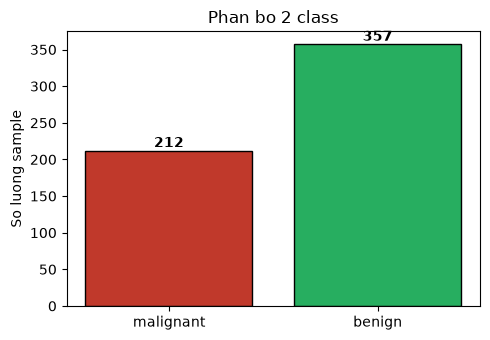

In [9]:
lop_da_so = ty_le.max() * 100
print(f"Tỉ lệ lớp đa số: {lop_da_so:.2f}%")
print()
print("Ý nghĩa: nếu một model 'ngu' luôn đoán mọi mẫu đều thuộc lớp đa số,")
print(f"nó vẫn đạt accuracy = {lop_da_so:.2f}% mà không học được gì cả.")
print("=> Accuracy KHÔNG phải chỉ số đáng tin cho dataset này.")

# Biểu đồ cột cho trực quan
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(data.target_names, dem.values, color=["#c0392b", "#27ae60"], edgecolor="black")
for i, v in enumerate(dem.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
ax.set_ylabel("So luong sample")
ax.set_title("Phan bo 2 class")
plt.tight_layout()
plt.show()

## Phần 5 – Tìm 10 cặp feature có |correlation| cao nhất

### Công thức hệ số tương quan Pearson

$$r_{XY} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$$

**So sánh với Bài 1.1:** công thức cosine similarity mà bạn đã tự code là

$$\cos(\theta) = \frac{\vec{a}\cdot\vec{b}}{\|\vec{a}\|\,\|\vec{b}\|}$$

Hai công thức **giống hệt nhau về cấu trúc**. Khác biệt duy nhất: Pearson trừ giá trị trung bình khỏi mỗi vector trước khi tính. Nói cách khác:

> **Correlation = cosine similarity của hai vector đã được "căn giữa" về gốc toạ độ.**

Vì vậy `r` cũng luôn nằm trong đoạn [-1, 1], đúng như cosine similarity.

### Bẫy kỹ thuật cần tránh

Ma trận correlation 30×30 có 900 ô, nhưng chỉ có $\frac{30 \times 29}{2} = 435$ cặp thực sự khác nhau, vì:
- 30 ô trên **đường chéo** luôn bằng 1 (một feature tương quan hoàn hảo với chính nó)
- Ma trận **đối xứng**: ô (A,B) và ô (B,A) là cùng một cặp

Nếu không lọc, top 10 sẽ toàn là đường chéo và các cặp trùng. Ta dùng `np.triu(..., k=1)` để chỉ lấy **tam giác trên, không tính đường chéo**.

In [10]:
# Ma trận tương quan 30x30
corr = X.corr()

# Tạo mặt nạ: True ở tam giác TRÊN, k=1 nghĩa là BỎ đường chéo
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

# where(mask) giữ lại giá trị ở vị trí True, các vị trí còn lại thành NaN
# stack() ép bảng 2 chiều thành danh sách dài, tự động bỏ NaN
cap = corr.where(mask).stack().reset_index()
cap.columns = ["feature_1", "feature_2", "correlation"]

# Đề bài yêu cầu ABSOLUTE correlation => lấy trị tuyệt đối để xếp hạng
cap["abs_correlation"] = cap["correlation"].abs()

print("Tổng số cặp feature khác nhau:", len(cap))
print("Kiểm tra công thức 30*29/2   :", 30 * 29 // 2)

Tổng số cặp feature khác nhau: 900
Kiểm tra công thức 30*29/2   : 435


In [11]:
top10 = cap.sort_values("abs_correlation", ascending=False).head(10).reset_index(drop=True)
top10.index = top10.index + 1   # đánh số từ 1 cho dễ đọc
top10

,feature_1,feature_2,correlation,abs_correlation
1,mean radius,mean perimeter,0.9979,0.9979
2,worst radius,worst perimeter,0.9937,0.9937
3,mean radius,mean area,0.9874,0.9874
4,mean perimeter,mean area,0.9865,0.9865
5,worst radius,worst area,0.9840,0.9840
6,worst perimeter,worst area,0.9776,0.9776
7,radius error,perimeter error,0.9728,0.9728
8,mean perimeter,worst perimeter,0.9704,0.9704
9,mean radius,worst radius,0.9695,0.9695
10,mean perimeter,worst radius,0.9695,0.9695


In [12]:
print("Số cặp có |r| > 0.9 :", (cap["abs_correlation"] > 0.9).sum())
print("Số cặp có |r| > 0.8 :", (cap["abs_correlation"] > 0.8).sum())
print("Số cặp có |r| < 0.1 :", (cap["abs_correlation"] < 0.1).sum())
print()
print("Cặp có tương quan ÂM mạnh nhất:")
print(cap.sort_values("correlation").head(3).to_string(index=False))

Số cặp có |r| > 0.9 : 21
Số cặp có |r| > 0.8 : 44
Số cặp có |r| < 0.1 : 58

Cặp có tương quan ÂM mạnh nhất:
     feature_1              feature_2  correlation  abs_correlation
   mean radius mean fractal dimension      -0.3116           0.3116
     mean area mean fractal dimension      -0.2831           0.2831
mean perimeter mean fractal dimension      -0.2615           0.2615


### Phân tích bổ sung: feature nào liên quan mạnh nhất tới nhãn?

Phần này không nằm trong yêu cầu, nhưng rất hữu ích khi nghiệm thu vì nó dẫn thẳng tới câu hỏi về quan hệ nhân quả.

Nhắc lại quy ước nhãn: **0 = malignant (ác tính)**, **1 = benign (lành tính)**. Do đó tương quan **âm** với `target` nghĩa là: giá trị feature càng lớn thì khả năng ác tính càng cao.

In [13]:
corr_target = X.corrwith(y).sort_values()

print("8 feature có liên hệ mạnh nhất với khối u ÁC TÍNH (tương quan âm mạnh):")
print(corr_target.head(8).to_string())
print()
print("5 feature gần như KHÔNG liên quan tới nhãn:")
print(corr_target.abs().sort_values().head(5).to_string())

8 feature có liên hệ mạnh nhất với khối u ÁC TÍNH (tương quan âm mạnh):
worst concave points   -0.7936
worst perimeter        -0.7829
mean concave points    -0.7766
worst radius           -0.7765
mean perimeter         -0.7426
worst area             -0.7338
mean radius            -0.7300
mean area              -0.7090

5 feature gần như KHÔNG liên quan tới nhãn:
symmetry error            0.0065
texture error             0.0083
mean fractal dimension    0.0128
smoothness error          0.0670
fractal dimension error   0.0780


## Phần 6 – Histogram cho 5 feature

Histogram chia trục giá trị thành các khoảng (bin) và đếm xem mỗi khoảng có bao nhiêu sample. Nó cho ta thấy **hình dạng phân phối** — điều mà bảng mean/std không thể hiện được.

Tôi chọn 5 feature thuộc các nhóm khác nhau để so sánh được nhiều dạng phân phối.

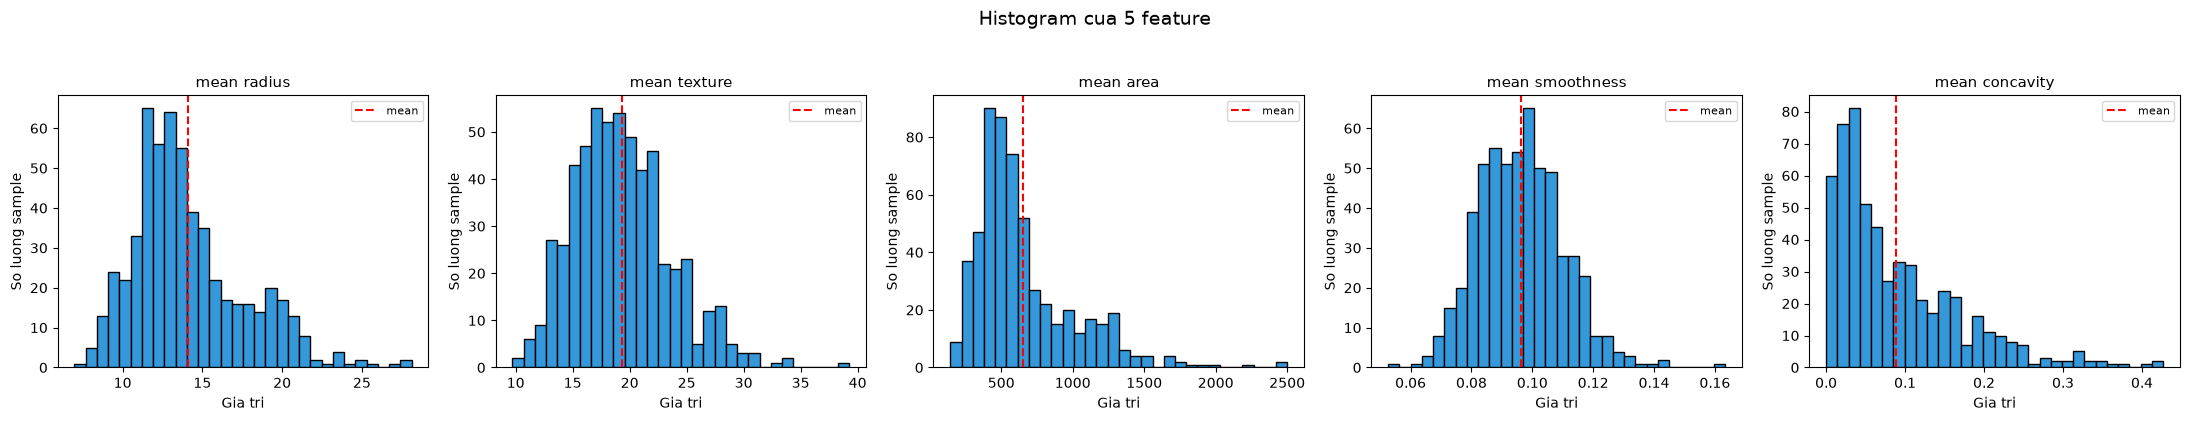

In [14]:
nam_feature = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness",
    "mean concavity",
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, ten in zip(axes, nam_feature):
    ax.hist(X[ten], bins=30, color="#3498db", edgecolor="black")
    ax.axvline(X[ten].mean(), color="red", linestyle="--", linewidth=1.5, label="mean")
    ax.set_title(ten, fontsize=11)
    ax.set_xlabel("Gia tri")
    ax.set_ylabel("So luong sample")
    ax.legend(fontsize=8)

plt.suptitle("Histogram cua 5 feature", fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

In [15]:
# Độ lệch (skewness): 0 = đối xứng, > 0 = lệch phải (đuôi dài bên phải), < 0 = lệch trái
print("ĐỘ LỆCH (skewness) CỦA 5 FEATURE ĐÃ VẼ:")
print(X[nam_feature].skew().round(3).to_string())
print()
print("6 FEATURE LỆCH NHẤT TRONG TOÀN BỘ DATASET:")
print(X.skew().sort_values(ascending=False).head(6).round(3).to_string())

ĐỘ LỆCH (skewness) CỦA 5 FEATURE ĐÃ VẼ:
mean radius       0.9420
mean texture      0.6500
mean area         1.6460
mean smoothness   0.4560
mean concavity    1.4010

6 FEATURE LỆCH NHẤT TRONG TOÀN BỘ DATASET:
area error                5.4470
concavity error           5.1100
fractal dimension error   3.9240
perimeter error           3.4440
radius error              3.0890
smoothness error          2.3140


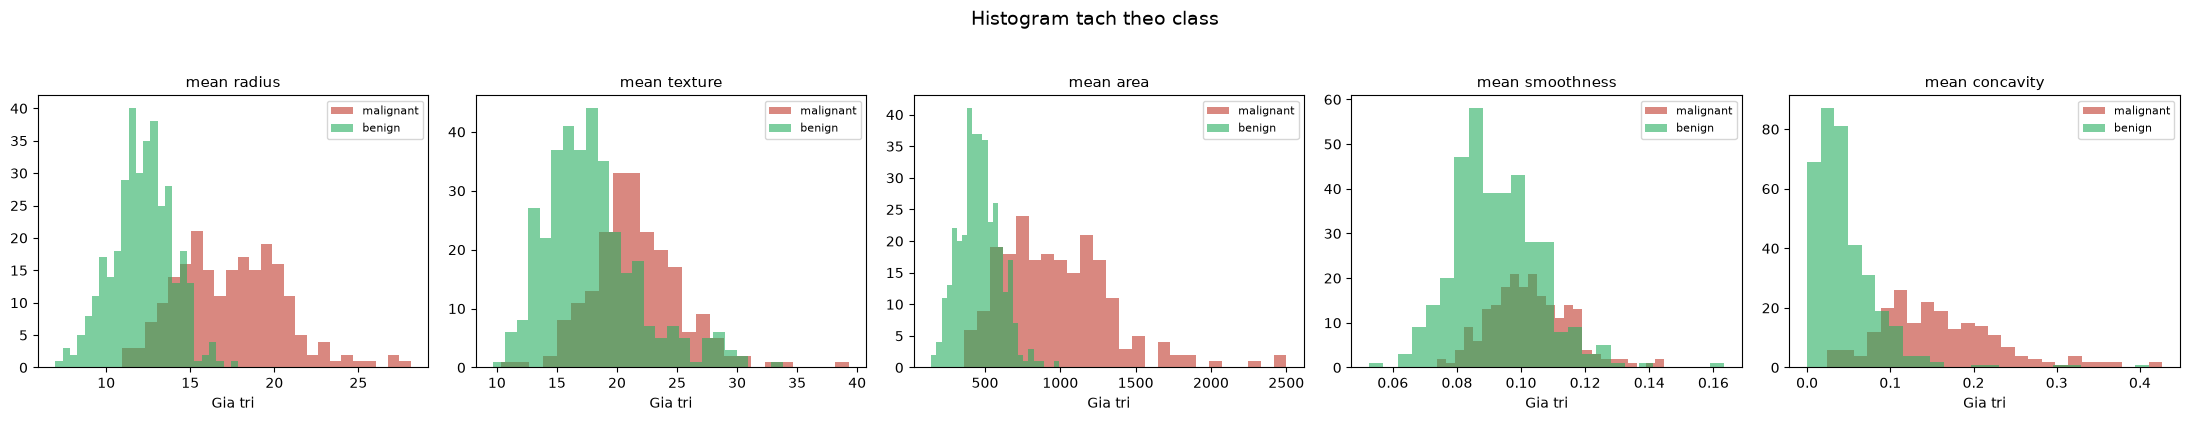

In [16]:
# Tách histogram theo class để thấy 2 nhóm có phân biệt được không
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, ten in zip(axes, nam_feature):
    ax.hist(X[y == 0][ten], bins=25, alpha=0.6, label="malignant", color="#c0392b")
    ax.hist(X[y == 1][ten], bins=25, alpha=0.6, label="benign", color="#27ae60")
    ax.set_title(ten, fontsize=11)
    ax.set_xlabel("Gia tri")
    ax.legend(fontsize=8)

plt.suptitle("Histogram tach theo class", fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

## Phần 7 – Correlation matrix cho 10 feature đầu

Heatmap là ma trận tương quan được tô màu: đỏ = tương quan dương mạnh, xanh = tương quan âm mạnh, trắng = gần như không liên quan.

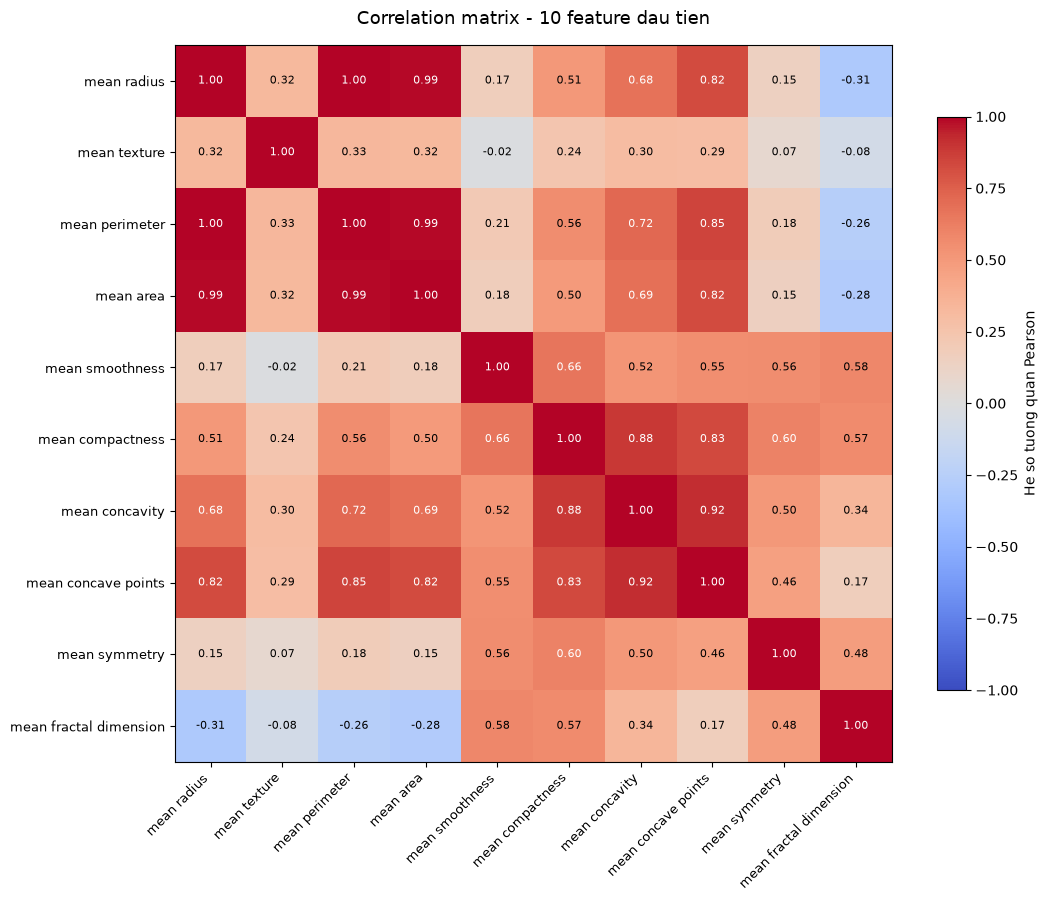

In [17]:
corr10 = X.iloc[:, :10].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr10, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr10.columns)))
ax.set_yticks(range(len(corr10.columns)))
ax.set_xticklabels(corr10.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr10.columns, fontsize=9)

# Ghi giá trị số vào từng ô
for i in range(len(corr10)):
    for j in range(len(corr10)):
        gia_tri = corr10.iloc[i, j]
        mau_chu = "white" if abs(gia_tri) > 0.6 else "black"
        ax.text(j, i, f"{gia_tri:.2f}", ha="center", va="center",
                fontsize=8, color=mau_chu)

fig.colorbar(im, ax=ax, label="He so tuong quan Pearson", shrink=0.8)
ax.set_title("Correlation matrix - 10 feature dau tien", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## Phần 8 – 5 nhận xét rút ra từ dữ liệu

### Nhận xét 1 — Dữ liệu sạch về mặt kỹ thuật, nhưng "sạch" không có nghĩa là "không cần kiểm tra"

Toàn bộ 569 × 30 = 17.070 ô đều có giá trị, không có `NaN`, không có `inf`, không có dòng trùng lặp, và cả 30 cột đều là `float64`. Không cần bất kỳ bước xử lý missing value nào.

Tuy nhiên đây là dataset mẫu đã được làm sạch sẵn. Trong dự án thật, `isnull()` trả về 0 vẫn chưa đủ kết luận: dữ liệu bẩn thường ẩn dưới dạng giá trị thay thế như `-1`, `0`, hoặc `999` — những giá trị này hợp lệ về kiểu dữ liệu nên `isnull()` không bắt được.

### Nhận xét 2 — Hai class mất cân bằng nhẹ, khiến accuracy trở thành chỉ số dễ gây hiểu lầm

Dataset có 357 mẫu benign (62,74%) và 212 mẫu malignant (37,26%), tỉ lệ xấp xỉ 1,68 : 1.

Hệ quả trực tiếp: một model chỉ luôn dự đoán "benign" cho mọi mẫu sẽ đạt accuracy 62,74% mà không học được gì. Vì vậy khi đánh giá model ở các bài sau, cần dùng **precision, recall, F1-score và confusion matrix** thay vì accuracy.

Trong bài toán y tế này, **recall của lớp malignant là chỉ số quan trọng nhất**: bỏ sót một khối u ác tính (false negative) nguy hiểm hơn nhiều so với báo động nhầm một khối u lành tính (false positive).

### Nhận xét 3 — Thang đo giữa các feature chênh lệch tới hơn 200.000 lần, bắt buộc phải chuẩn hoá

| Feature | Mean | Std |
|---------|------|-----|
| `worst area` | 880,58 | 569,36 |
| `mean area` | 654,89 | 351,91 |
| `fractal dimension error` | 0,0038 | 0,0026 |

Tỉ lệ chênh lệch giữa mean lớn nhất và nhỏ nhất là khoảng **232.000 lần**.

Điều này nối trực tiếp với hàm `euclidean_distance` tôi đã tự viết ở Bài 1.1. Khi tính khoảng cách Euclid, mỗi feature đóng góp một số hạng bình phương. Với chênh lệch thang đo như trên, `worst area` sẽ chiếm gần như toàn bộ giá trị khoảng cách, còn `fractal dimension error` bị nuốt chửng hoàn toàn — bất kể nó có ý nghĩa y học hay không.

Kết luận: mọi thuật toán dựa trên khoảng cách hoặc gradient (KNN, SVM, K-Means, hồi quy logistic, mạng nơ-ron) **bắt buộc** phải chuẩn hoá dữ liệu trước. Cây quyết định và Random Forest thì không cần, vì chúng chỉ so sánh ngưỡng trên từng feature riêng lẻ.

### Nhận xét 4 — Đa cộng tuyến rất nghiêm trọng: nhiều feature chỉ là bản sao toán học của nhau

Trong 435 cặp feature, có **21 cặp với |r| > 0,9** và 44 cặp với |r| > 0,8. Cả 10 cặp đứng đầu đều có |r| ≥ 0,969, dẫn đầu là `mean radius` – `mean perimeter` với r = 0,9979.

Nguyên nhân không phải ngẫu nhiên mà là **quan hệ hình học tất định**: với một hình gần tròn, chu vi = 2πr và diện tích = πr². Ba feature radius, perimeter, area về bản chất đang đo cùng một thứ — kích thước khối u — chỉ khác đơn vị. Tương tự, ba nhóm `mean` / `error` / `worst` được tính từ cùng một tập phép đo gốc nên tương quan chéo rất cao.

Hệ quả: 30 feature chứa lượng thông tin thực tế ít hơn nhiều so với con số 30. Điều này gây bất ổn hệ số trong hồi quy tuyến tính và làm tăng nguy cơ overfitting. Hướng xử lý về sau: loại bỏ feature dư thừa, hoặc dùng PCA để giảm chiều.

### Nhận xét 5 — Phân phối lệch phải mạnh, đặc biệt ở nhóm feature `error`

Không feature nào có phân phối chuẩn. Nhóm `error` lệch nghiêm trọng nhất:

| Feature | Skewness |
|---------|----------|
| `area error` | 5,447 |
| `concavity error` | 5,110 |
| `fractal dimension error` | 3,924 |
| `mean area` | 1,646 |
| `mean radius` | 0,942 |

Skewness dương lớn nghĩa là phần lớn mẫu tập trung ở giá trị thấp, kèm một đuôi dài các giá trị rất cao. Cụ thể `area error` có mean 40,34 nhưng max lên tới 542,20 — gấp hơn 13 lần giá trị trung bình.

Hai hệ quả cần lưu ý:
1. Với phân phối lệch, **mean bị các giá trị cực đoan kéo lệch**, nên median mô tả "giá trị điển hình" tốt hơn.
2. Các giá trị ở đuôi phải có thể là outlier kỹ thuật, nhưng cũng có thể chính là **tín hiệu bệnh lý quan trọng** — histogram tách theo class ở Phần 6 cho thấy đuôi phải chủ yếu là mẫu malignant. Do đó **không được xoá chúng như outlier thông thường**.

Nếu cần đưa về gần chuẩn hơn, có thể dùng phép biến đổi log hoặc Box-Cox.

## Phụ lục – Chuẩn bị cho buổi nghiệm thu

### Câu hỏi 1: mean, std, correlation có ý nghĩa gì?

**Mean (trung bình)** là tổng chia cho số phần tử, mô tả vị trí trung tâm của dữ liệu. Điểm yếu: rất nhạy với giá trị cực đoan. Với `area error` (mean 40,34; max 542,20), giá trị trung bình bị đuôi phải kéo lên cao hơn giá trị điển hình thực tế.

**Std (độ lệch chuẩn)** là căn bậc hai của phương sai, đo mức phân tán của dữ liệu quanh giá trị trung bình. Đơn vị của std trùng với đơn vị của dữ liệu gốc, nên đọc trực tiếp được. std nhỏ nghĩa là các mẫu tập trung gần nhau; std lớn nghĩa là dữ liệu trải rộng.

Điểm mấu chốt: **mean và std phải đọc cùng nhau**. Riêng mean không cho biết gì về độ tin cậy của con số đó.

Muốn so sánh mức phân tán giữa các feature khác đơn vị, phải dùng hệ số biến thiên CV = std / mean, vì std của `mean area` (351,91) và std của `mean smoothness` (0,0141) không so sánh trực tiếp được.

**Correlation (hệ số tương quan Pearson)** đo mức độ chặt chẽ của quan hệ **tuyến tính** giữa hai biến, nhận giá trị trong [-1, 1]:
- r = +1: quan hệ tuyến tính đồng biến hoàn hảo
- r = 0: không có quan hệ **tuyến tính**
- r = -1: quan hệ tuyến tính nghịch biến hoàn hảo

Về mặt hình học, correlation chính là cosine similarity giữa hai vector đã trừ đi giá trị trung bình.

Hai cảnh báo quan trọng:
1. **r = 0 không có nghĩa là hai biến độc lập.** Nếu y = x² với x đối xứng quanh 0, thì r ≈ 0 mặc dù y hoàn toàn được xác định bởi x. Pearson mù với quan hệ phi tuyến.
2. **r rất nhạy với outlier.** Vài điểm cực đoan có thể tạo ra hoặc phá huỷ một hệ số tương quan.

### Câu hỏi 2: vì sao correlation không chứng minh quan hệ nhân quả?

Câu trả lời ngắn gọn: correlation chỉ mô tả **hai biến biến thiên cùng nhau**, còn nhân quả khẳng định **biến này gây ra biến kia**. Đó là hai mệnh đề hoàn toàn khác nhau. Khi quan sát thấy A tương quan với B, có ít nhất bốn khả năng:

**1. Chiều nhân quả có thể ngược lại.** Correlation hoàn toàn đối xứng: r(A,B) luôn bằng r(B,A). Bản thân con số không chứa bất kỳ thông tin nào về chiều.

**2. Biến gây nhiễu (confounding variable).** Một nguyên nhân thứ ba C tác động lên cả A và B, tạo ra tương quan giả giữa chúng. Ví dụ kinh điển: doanh số kem và số vụ đuối nước tương quan dương rất mạnh, nhưng kem không gây đuối nước — nhiệt độ mùa hè là nguyên nhân chung của cả hai.

Ngay trong dataset này cũng có ví dụ rõ ràng: `mean radius` và `mean perimeter` có r = 0,9979, nhưng bán kính không "gây ra" chu vi. Cả hai đều là hệ quả toán học của cùng một thực thể là kích thước khối u, theo công thức chu vi = 2πr.

**3. Trùng hợp ngẫu nhiên.** Với 435 cặp feature được kiểm tra, việc một số cặp có tương quan cao thuần tuý do may rủi là điều thống kê dự đoán được. Càng kiểm tra nhiều giả thuyết, càng dễ gặp tương quan giả — đây là vấn đề *multiple comparisons*.

**4. Thiên lệch chọn mẫu.** Dataset này chỉ gồm những người **đã đi khám và đã được chỉ định sinh thiết**. Đây không phải mẫu ngẫu nhiên từ dân số chung, nên các mối quan hệ quan sát được có thể không đúng ngoài phạm vi nhóm này.

**Vì sao điều này quan trọng với chính bài toán đang làm:** `worst concave points` có tương quan -0,7936 với nhãn, tức khối u có nhiều điểm lõm sâu thì khả năng ác tính cao. Nhưng dữ liệu này **không** cho phép kết luận rằng điểm lõm *gây ra* ung thư. Nhiều khả năng cả hai đều là biểu hiện của cùng một quá trình sinh học bên dưới: tế bào ác tính phát triển mất trật tự, làm biến dạng đường viền nhân tế bào.

Với mục tiêu **dự đoán**, phân biệt nhân quả hay không không quan trọng — tương quan đủ để model hoạt động tốt. Nhưng với mục tiêu **can thiệp** (thay đổi X để đạt được Y), bắt buộc phải có bằng chứng nhân quả. Muốn có bằng chứng đó cần **thí nghiệm có đối chứng ngẫu nhiên (RCT)**, hoặc các phương pháp suy luận nhân quả từ dữ liệu quan sát như biến công cụ, hồi quy gián đoạn, difference-in-differences.

Một câu tổng kết đáng nhớ: *correlation là điều kiện cần nhưng không đủ để kết luận nhân quả.*